In [1]:
# %% 1: Environment & Dependency Imports
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import keras
from keras.models import Sequential
from keras import layers

In [2]:
print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

TensorFlow Version: 2.21.0
Keras Version: 3.15.1


In [6]:
# %% 2: Data Cleaning (Removing Corrupt Images)
# The Microsoft PetImages dataset contains a few corrupted or truncated JPEG images 
# (e.g., empty bytes or broken headers) that cause tf.image.decode_image to crash during training.
# This cell scans your directory and safely deletes any invalid files before loading.

DATASET_PATH = r"D:\ml\image classification"

def remove_corrupt_images(directory):
    print("Scanning for corrupted images... This might take a minute.")
    corrupt_count = 0
    processed_count = 0
    
    for root, _, files in os.walk(directory):
        for file in files:
            # Only check image files
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_path = os.path.join(root, file)
                processed_count += 1
                try:
                    # Read raw file bytes
                    img_bytes = tf.io.read_file(file_path)
                    # Attempt a full decode using TensorFlow's native image engine
                    tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
                except Exception:
                    print(f"Corrupt file isolated and removed: {file_path}")
                    try:
                        os.remove(file_path)
                        corrupt_count += 1
                    except Exception as e:
                        print(f"Failed to delete {file_path}: {e}")
                        
    print(f"Scan complete. Inspected {processed_count} files. Successfully removed {corrupt_count} corrupt images.")

# Execute the cleaning function
remove_corrupt_images(DATASET_PATH)


Scanning for corrupted images... This might take a minute.
Corrupt file isolated and removed: D:\ml\image classification\Cat\10404.jpg
Corrupt file isolated and removed: D:\ml\image classification\Cat\4351.jpg
Corrupt file isolated and removed: D:\ml\image classification\Dog\11233.jpg
Corrupt file isolated and removed: D:\ml\image classification\Dog\11912.jpg
Corrupt file isolated and removed: D:\ml\image classification\Dog\2317.jpg
Corrupt file isolated and removed: D:\ml\image classification\Dog\2494.jpg
Corrupt file isolated and removed: D:\ml\image classification\Dog\9500.jpg
Scan complete. Inspected 24999 files. Successfully removed 7 corrupt images.


In [7]:
# %% 3: Dataset Loading (Automatic 80/20 Split)
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 123

In [8]:
# training subset
print("Loading training subset...")
train_ds = keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Loading training subset...
Found 24991 files belonging to 2 classes.
Using 19993 files for training.


In [9]:
# validation subset
print("Loading validation subset...")
validation_ds = keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Loading validation subset...
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [10]:
# Extract and print class identities mapped by directory scanner
class_names = train_ds.class_names
print("Detected Class Labels:", class_names)

Detected Class Labels: ['Cat', 'Dog']


In [11]:
# %% 4: Memory Optimization Pipeline
# Optimize I/O operations to prevent CPU bottlenecks during GPU processing
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
print("Dataset optimization layers applied successfully.")

Dataset optimization layers applied successfully.


In [12]:
# %% 5: Defining CNN Model with Preprocessing & Augmentation
# Augmentation layers are integrated directly into the model logic execution sweep
model = Sequential([
    # Explicitly define the input shape using an Input layer to satisfy Keras 3 requirements
    layers.Input(shape=(150, 150, 3)),
    
    # Standardize pixel values dynamically on the GPU
    layers.Rescaling(1.0/255.0),
    
    # Inline Data Augmentation to limit overfitting
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    
    # First Conv Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Second Conv Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Third Conv Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Fourth Conv Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Dense Classification Head
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # regularizer drop mask
    layers.Dense(1, activation='sigmoid') # Binary mapping (0 or 1)
])

In [13]:
# Compile model configurations
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# %% 6: Model Optimization Training Loop
# Adjust EPOCHS down if testing configurations quickly
EPOCHS = 20

print("Initiating training sequence...")
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    verbose=1
)
print("Training execution routine finalized.")

Initiating training sequence...
Epoch 1/20


c:\anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 252ms/step - accuracy: 0.6210 - loss: 0.6442 - val_accuracy: 0.7099 - val_loss: 0.5657
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 262ms/step - accuracy: 0.7045 - loss: 0.5664 - val_accuracy: 0.7543 - val_loss: 0.5128
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 248ms/step - accuracy: 0.7362 - loss: 0.5246 - val_accuracy: 0.7819 - val_loss: 0.4605
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 700s 1s/step - accuracy: 0.7643 - loss: 0.4913 - val_accuracy: 0.7975 - val_loss: 0.4386
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 157s 252ms/step - accuracy: 0.7756 - loss: 0.4704 - val_accuracy: 0.7727 - val_loss: 0.4643
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.7869 - loss: 0.4508 - val_accuracy: 0.7969 - val_loss: 0.4272
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.8008 - loss: 0.4317 - val_accuracy: 0.8209 - val_loss: 0.3881
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 239ms/step - accuracy: 0.8052 - loss: 0.4179 

In [15]:
# %% 7: Plotting Metric Performance Charts
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

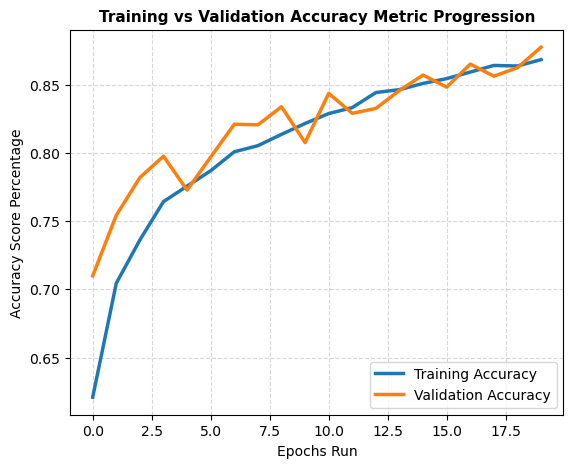

In [16]:
plt.figure(figsize=(14, 5))

# Accuracy curves subplot panel
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2.5)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2.5)
plt.legend(loc='lower right', fontsize=10)
plt.title('Training vs Validation Accuracy Metric Progression', fontsize=11, fontweight='bold')
plt.xlabel('Epochs Run')
plt.ylabel('Accuracy Score Percentage')
plt.grid(True, linestyle='--', alpha=0.5)

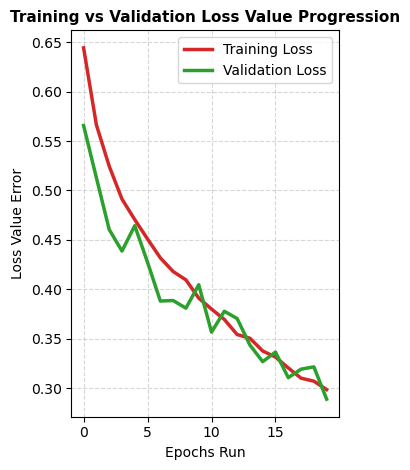

In [17]:
# Loss curves subplot panel
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2.5)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2.5)
plt.legend(loc='upper right', fontsize=10)
plt.title('Training vs Validation Loss Value Progression', fontsize=11, fontweight='bold')
plt.xlabel('Epochs Run')
plt.ylabel('Loss Value Error')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [37]:
# %% 8: Single Image Target Inference Testing with Confidence Parameters
def predict_external_image(target_file_path=r"D:\ml\image classification\test.jpg", min_confidence=0.75):
    """
    Loads and evaluates an individual image.
    If the model's confidence for either class drops below min_confidence, 
    it will flag the image as UNIDENTIFIED.
    """
    try:
        # 1. Verify file existence
        if not os.path.exists(target_file_path):
            print(f"Error: The image file was not found at path: {target_file_path}")
            return
            
        # 2. Load and preprocess image
        img = keras.preprocessing.image.load_img(target_file_path, target_size=IMAGE_SIZE)
        img_array = keras.preprocessing.image.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0)
        
        # 3. Predict raw probability score
        score_tensor = model.predict(img_batch, verbose=0)
        prediction_probability = float(score_tensor[0][0])       
        
        print("\n--- Inference Result Summary ---")
        
        # Calculate distinct directional class confidence scores
        dog_confidence = prediction_probability
        cat_confidence = 1.0 - prediction_probability
        
        # 4. Handle prediction outputs using strict confidence bounds
        if dog_confidence >= min_confidence:
            print(f"Classification Result: DOG ({dog_confidence * 100:.2f}% confidence)")
            
        elif cat_confidence >= min_confidence:
            print(f"Classification Result: CAT ({cat_confidence * 100:.2f}% confidence)")
            
        else:
            print(f"Classification Result: UNIDENTIFIED / UNKNOWN IMAGE")
            print(f"Reason: Model confidence falls below the {min_confidence * 100:.1f}% safety filter threshold.")
            print(f"Calculated Metrics -> Dog: {dog_confidence * 100:.2f}% | Cat: {cat_confidence * 100:.2f}%")
            
    except Exception as runtime_error:
        print(f"Inference process aborted for targeted file layout: {str(runtime_error)}")


In [38]:
# Execute test evaluation
TEST_IMAGE_PATH = r"D:\ml\image classification\test.jpg"
print(f"Running inference calculation on target file: {TEST_IMAGE_PATH}")

predict_external_image(TEST_IMAGE_PATH, min_confidence=0.75)

Running inference calculation on target file: D:\ml\image classification\test.jpg

--- Inference Result Summary ---
Classification Result: CAT (85.39% confidence)


In [39]:
# %% 9: Single Image Target Inference Testing for either cat or dog classification
def predict_external_image(target_file_path="D:\ml\image classification\test.jpg"):
    """
    Loads, processes dimensions, and evaluates an individual unseen image.
    """
    try:
        # 1. Verify if the file actually exists on the path provided
        if not os.path.exists(target_file_path):
            print(f"Error: The image file was not found at path: {target_file_path}")
            return
            
        # 2. Load and verify structural target image file matching model input dimensions
        img = keras.preprocessing.image.load_img(target_file_path, target_size=IMAGE_SIZE)
        img_array = keras.preprocessing.image.img_to_array(img)
        img_batch = np.expand_dims(img_array, axis=0) # Reshapes array layout to (1, 150, 150, 3)
        
        # 3. Calculate classification probability distribution signature
        score_tensor = model.predict(img_batch, verbose=0)
        
        # 4. Extract the exact float scalar value from the nested prediction array [[value]]
        prediction_probability = float(score_tensor[0][0])
        
        print("\n--- Inference Result Summary ---")
        # 5. Check standard binary classification threshold bounds (0: Cat, 1: Dog)
        if prediction_probability > 0.5:
            confidence = prediction_probability * 100
            print(f"Classification Result: DOG ({confidence:.2f}% confidence)")
        else:
            confidence = (1.0 - prediction_probability) * 100
            print(f"Classification Result: CAT ({confidence:.2f}% confidence)")
            
    except Exception as runtime_error:
        print(f"Inference process aborted for targeted file layout: {str(runtime_error)}")
# ==========================================
# ACTIVE INFERENCE EXECUTION BLOCK
# ==========================================
# Provide the full path to your local test image. 
# Make sure to keep the 'r' prefix before the path string to handle Windows backslashes correctly.
TEST_IMAGE_PATH = r"D:\ml\image classification\test.jpg"

print(f"Running inference calculation on target file: {TEST_IMAGE_PATH}")
predict_external_image(TEST_IMAGE_PATH)


Running inference calculation on target file: D:\ml\image classification\test.jpg

--- Inference Result Summary ---
Classification Result: CAT (85.39% confidence)
